In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv("data/S02-hw-dataset.csv")
type(data)

pandas.core.frame.DataFrame

In [15]:
data.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [17]:
data.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [18]:
data.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

In [40]:
data[data['age'].isna()]

,user_id,age,country,purchases,revenue
4,5,NaN,DE,6,1296
12,13,NaN,US,9,630


In [42]:
data[data.duplicated(keep=False)]

,user_id,age,country,purchases,revenue
9,10,24.0,RU,7,511
40,10,24.0,RU,7,511


In [28]:
data[data['age'] > 100]

,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


In [35]:
data[data['age'] < 10]

,user_id,age,country,purchases,revenue
20,21,5.0,RU,8,1488


In [36]:
data[(data['purchases'] > 0) & (data['revenue'] <= 0)]

,user_id,age,country,purchases,revenue
10,11,24.0,US,4,0


В 4 и 12 строках пропущены значения age \
В 9 и 40 строках идентичные данные \
В 5 строке возраст = 120 \
В 20 строке возраст = 5 (доход у 5-летнего?) \
В 10 строке при наличии покупок доход = 0

In [53]:
data.value_counts([data['age'], data['purchases']])

age    purchases
24.0    7           2
5.0     8           1
20.0    7           1
21.0    5           1
22.0    3           1
18.0    4           1
23.0    5           1
24.0    0           1
        4           1
        5           1
25.0    7           1
26.0    6           1
28.0    0           1
        2           1
31.0    2           1
        6           1
32.0    6           1
        11          1
33.0    6           1
34.0    7           1
35.0    3           1
        5           1
36.0    9           1
39.0    4           1
        7           1
42.0    4           1
43.0    3           1
45.0    2           1
46.0    0           1
47.0    3           1
        6           1
51.0    3           1
52.0    6           1
        7           1
54.0    6           1
55.0    1           1
57.0    7           1
120.0  -1           1
Name: count, dtype: int64

In [57]:
data.groupby('country').agg({'age': ['count', 'mean'], 
                             'purchases': ['count', 'mean'],
                             'revenue': ['count', 'mean']})

age            purchases           revenue             
        count       mean     count      mean   count         mean
country                                                          
CN          2  24.000000         2  4.500000       2  1054.000000
DE          5  34.600000         6  6.500000       6  1445.500000
FR         12  46.250000        12  4.250000      12   675.916667
RU         13  30.076923        13  4.769231      13   790.076923
US          7  36.714286         8  4.625000       8   557.375000

Франция и Россия являются наиболее представленными странами в датасете. США и Германия занимают средние позиции, в то время как Китай представлен минимально. \
Германия демонстрирует наивысшие средние показатели выручки на пользователя при относительно высоком среднем количестве покупок. При этом пользователи из США показывают самый низкий средний доход на пользователя. \
Америка должна доминировать в доходе, а тут показано наоборот.

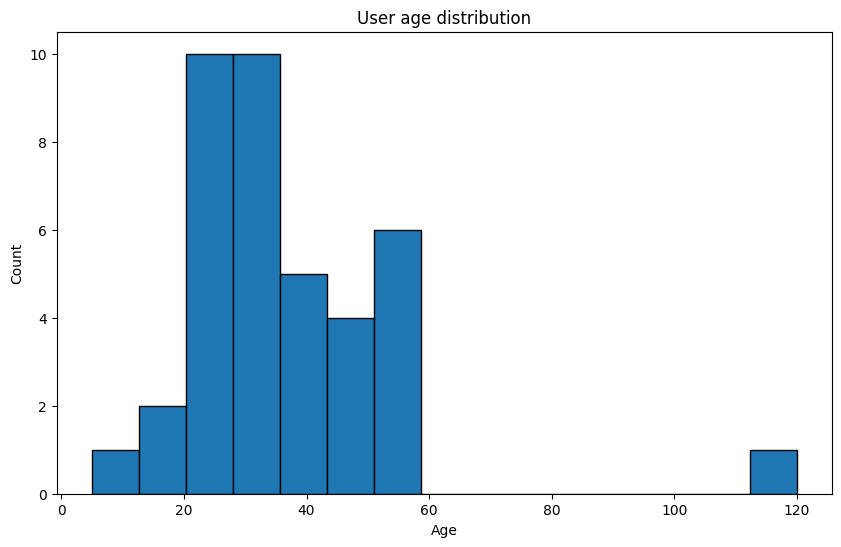

In [72]:
plt.figure(figsize=(10, 6))
plt.hist(data['age'].dropna(), bins=15, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title("User age distribution")
plt.savefig('figures/age_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

Гистограмма показывает бимодальное распределение возраста

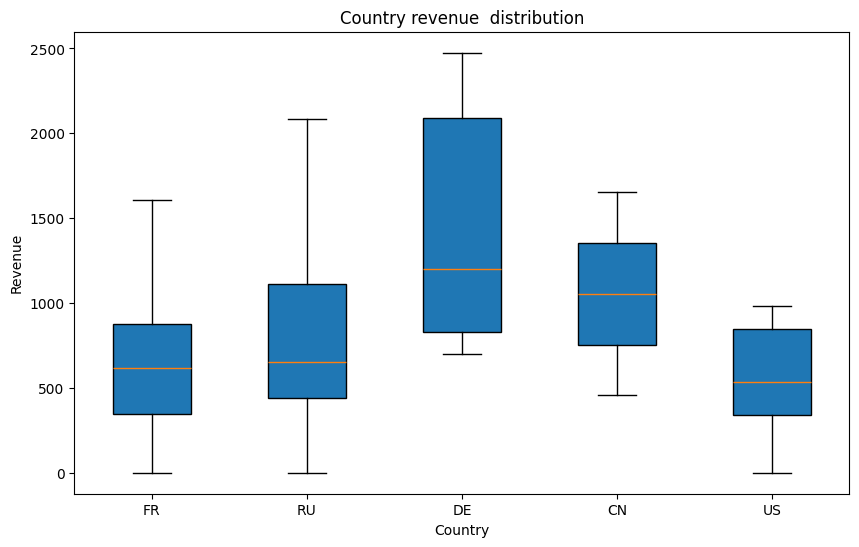

In [102]:
data_for_boxplot = [data[data['country']==c]['revenue'] for c in data['country'].unique()]
plt.figure(figsize=(10, 6))
plt.boxplot(data_for_boxplot, tick_labels=data['country'].unique(), patch_artist=True)
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.title("Country revenue  distribution")
plt.savefig('figures/revenue_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Боксплот демонстрирует значительные различия в распределении выручки между странами

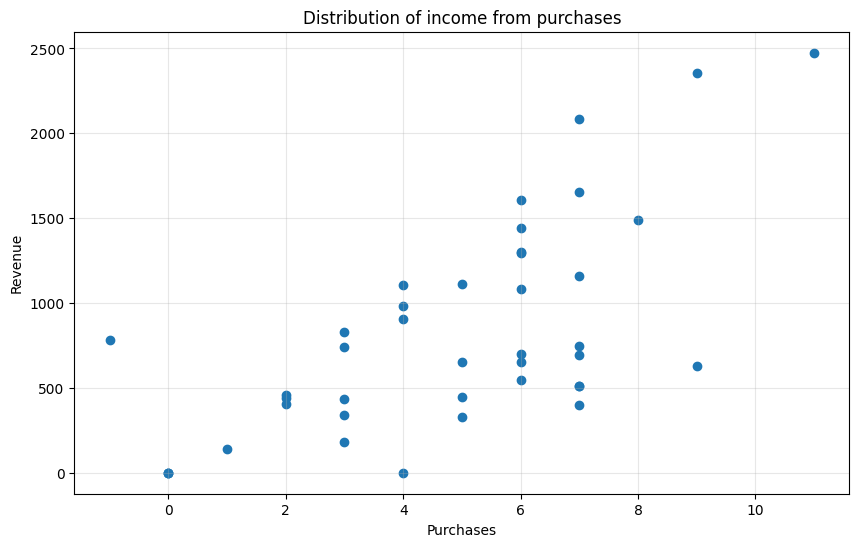

In [101]:
plt.figure(figsize=(10, 6))

plt.scatter(data['purchases'], data['revenue'])
plt.xlabel('Purchases')
plt.ylabel('Revenue')
plt.title('Distribution of income from purchases')

plt.grid(True, alpha=0.3)
plt.savefig('figures/purchases_vs_revenue_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Диаграмма рассеяния показывает ожидаемую положительную корреляцию между количеством покупок и выручкой